
📊 Model Comparison Results (1000 Dataset):

🔹 Random Forest
Accuracy : 0.81
Precision: 0.8529
Recall   : 0.6744
F1 Score : 0.7532
----------------------------------------
🔹 Logistic Regression
Accuracy : 0.755
Precision: 0.7403
Recall   : 0.6628
F1 Score : 0.6994
----------------------------------------
🔹 KNN
Accuracy : 0.7
Precision: 0.6512
Recall   : 0.6512
F1 Score : 0.6512
----------------------------------------

📌 Confusion Matrix - Random Forest



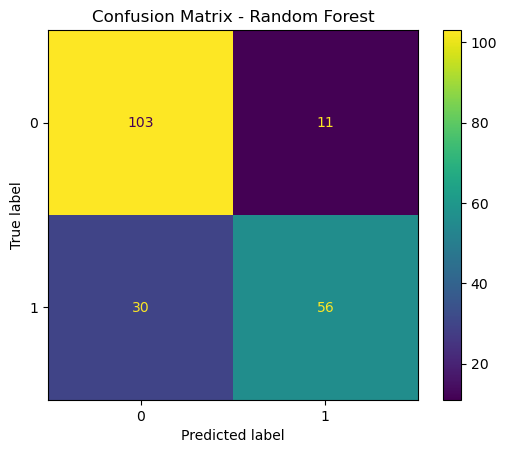

In [3]:
# ==========================================
# PRODUCT RECOMMENDATION - 3000 DATASET
# Model Comparison: RF, Logistic, KNN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1️⃣ Load New Dataset (3000 rows)
# ==========================================
df = pd.read_csv("product_realistic_unique_names.csv")

# Remove ID columns
df = df.drop(columns=["User_ID", "Product_ID"])

# Remove leakage column
df = df.drop(columns=["Cart_Added"])

# ==========================================
# 2️⃣ Encode Categorical Columns
# ==========================================
categorical_columns = ["Gender", "Location", "Product_Name", "Brand",
                       "Product_Type", "Category", "Search_Query"]

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder

# ==========================================
# 3️⃣ Split Features and Target
# ==========================================
X = df.drop("Bought", axis=1)
y = df["Bought"]

# Stratified split (important)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# 4️⃣ Scale Data (for LR & KNN)
# ==========================================
# ==========================================
# 4️⃣ Scale Data (for LR & KNN)
# ==========================================

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)
# ==========================================
# 5️⃣ Define Models
# ==========================================

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=1000,
        max_depth=20,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# ==========================================
# 6️⃣ Train and Evaluate
# ==========================================

print("\n📊 Model Comparison Results (1000 Dataset):\n")

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"🔹 {name}")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("-" * 40)

    # ✅ Confusion Matrix
print("\n📌 Confusion Matrix - Random Forest\n")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [4]:
# ==============================
# KEYWORD-BASED TOP 5 RECOMMENDATION
# ==============================

# Take user keyword
user_keyword = input("Enter product type (e.g., smartphone, shampoo, running shoes): ").lower()

# Load original dataset
original_df = pd.read_csv("product_realistic_unique_names.csv")

# Filter products based on keyword
filtered_df = original_df[
    original_df["Product_Type"].str.lower().str.contains(user_keyword)
]

if len(filtered_df) == 0:
    print("No matching products found.")
else:
    # Preprocess (same as training)
    processed_df = filtered_df.drop(columns=["User_ID", "Product_ID", "Cart_Added"])

    for column in categorical_columns:
        processed_df[column] = label_encoders[column].transform(processed_df[column])

    X_filtered = processed_df.drop("Bought", axis=1)

    # Use the best-performing model (Random Forest) for recommendation
    # Random Forest was trained on unscaled data, so no scaling is needed for X_filtered here.
    model_for_recommendation = models["Random Forest"]
    probabilities = model_for_recommendation.predict_proba(X_filtered)[:, 1]

    # Avoid SettingWithCopyWarning
    filtered_df = filtered_df.copy()

    # Convert probability to score out of 10
    filtered_df["Ratings"] = (probabilities * 10).round(2)

    # Sort and get Top 5
    top_5 = filtered_df.sort_values(
        by="Ratings",
        ascending=False
    )[["Product_Name", "Brand", "Category", "Ratings"]].head(5)

    print("\n🔥 Top 5 Recommended Products (Ratings):")
    print(top_5)



🔥 Top 5 Recommended Products (Ratings):
                Product_Name   Brand Category  Ratings
666  Nike HyperBoost Advance    Nike   Sports     9.78
71     Nike Air Zoom Pegasus    Nike   Sports     9.77
258     Nike HyperBoost Edge    Nike   Sports     9.75
795  Adidas PowerRun Advance  Adidas   Sports     9.63
130       Nike UrbanStep Max    Nike   Sports     9.58
